# Quantization tables
I computed the quantization tables, and made sure that they are the same for all the images, by comparing them in some images.

I defined a list of ten qualities. Each time, I opened the original image and saved it at the desired quality. Then, I open the image and read its quantization tables.

In [ ]:
! pip install jpegio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 MB 7.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for jpegio: filename=jpegio-0.2.8-cp312-cp312-linux_x86_64.whl size=1277055 sha256=24df966f5b604e066346288c05a3dcc20bc3f0f6cae2791f59a403d60a2763d5
  Stored in directory: /root/.cache/pip/wheels/4e/5f/d9/3898c36bd7e9166a13a514d61f7ddd7310c192bfb443e758f8
Successfully built jpegio


In [ ]:
from PIL import Image
import numpy as np
import jpegio
import matplotlib.pyplot as plt
import os
import torch
import glob


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/tesi/" if 'google.colab' in str(get_ipython()) else "."
sample_jpeg_path = os.path.join(BASE_DIR, "experiments/tables/reference_image/000001.jpg")

SAVE_PATH = os.path.join(BASE_DIR, "assets/quant_tables2.pt")

## computing quantization tables

In [ ]:
# qualities = [100, 25, 15, 10, 8, 7, 6, 5, 4, 3, 1]
# qualities = list(range(100, -1, -10))

qualities = [100, 20, 13, 9, 7, 5, 3, 2, 1, 1]

Here I save the images locally at all the different qualities.

In [ ]:
current_img = Image.open(sample_jpeg_path)
for i, q in enumerate(qualities):
    current_img.save(f'output_img_quality_{i}.jpg', quality=q)
    current_img = Image.open(f'output_img_quality_{i}.jpg').convert('RGB')

plotting images

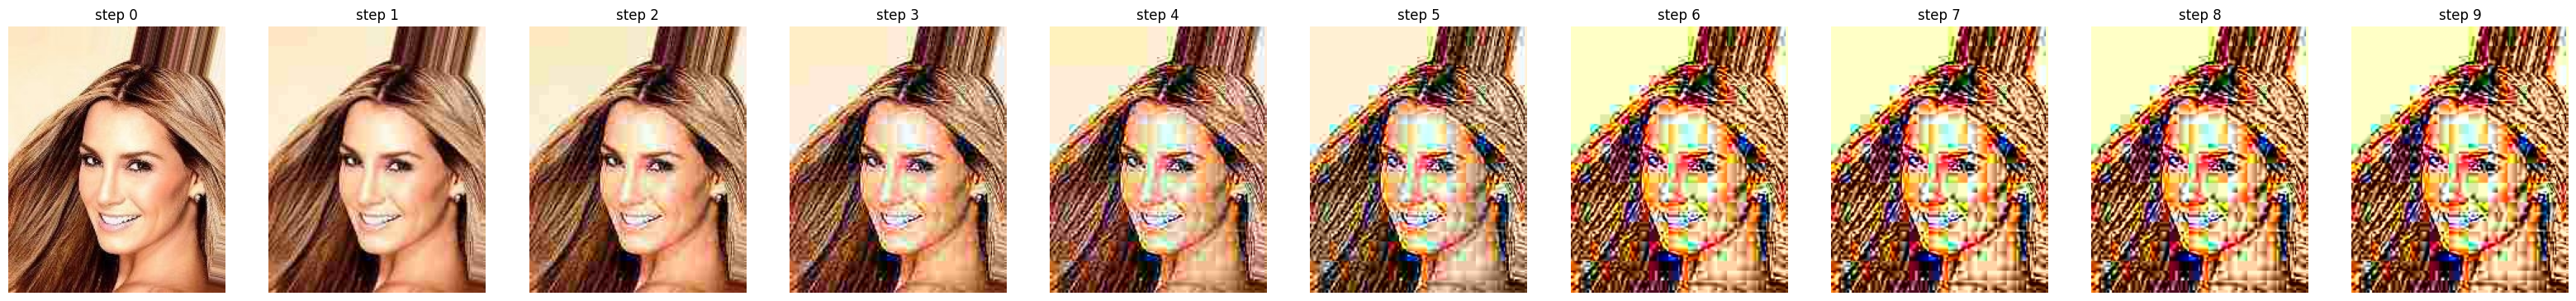

In [ ]:
num_images = len(qualities)
plt.figure(figsize=(num_images * 4, 5))

for i in range(num_images):
    # saved_img = jpegio.read(f'output_img_quality_{qualities[i]}.jpg')
    saved_img = Image.open(f'output_img_quality_{i}.jpg').convert('RGB')
    plt.subplot(1, num_images, i + 1)
    plt.imshow(saved_img)
    plt.title(f'step {i}')
    plt.axis('off')

printing quantization tables

In [ ]:
for i in range(num_images):
    saved_img = jpegio.read(f'output_img_quality_{i}.jpg')
    for (quant_table, original_table) in zip(saved_img.quant_tables, jpeg_data.quant_tables):
        print(f"Quality {qualities[i]}:\n{quant_table}")

sotto ho messo modi diversi per salvare le tabelle. cambiare se necessario. cambia anche estensione file in ```SAVE_PATH```



## checking multiples

In [ ]:
unique_luminance_tables = {}
unique_chrominance_tables = {}

print("Collecting unique quantization tables for each quality...")
for q_val in qualities:
    # I pick one image from which extract the tables
    sample_img_paths = glob.glob(f'temp_quality_{q_val}_*.jpg')
    if not sample_img_paths:
        print(f"No images found for quality {q_val}. Skipping.")
        continue

    sample_img_path = sample_img_paths[0]

    try:
        jpeg_data = jpegio.read(sample_img_path)
        unique_luminance_tables[q_val] = np.array(jpeg_data.quant_tables[0], dtype=np.int32)
        unique_chrominance_tables[q_val] = np.array(jpeg_data.quant_tables[1], dtype=np.int32)
    except Exception as e:
        print(f"Error reading {sample_img_path} for quality {q_val}: {e}. Skipping.")

def check_if_multiple(table1, table2, name1, name2):
    """
    Checks if table1 is an integer multiple of table2, or vice versa.
    Returns a string describing the relationship or None if no simple multiple.
    """
    if np.array_equal(table1, table2):
        return None
    # Check if table1 is multiple of table2 (table1 = k * table2)

    # EDGE CASES: zeros
    # Where table2 is zero, table1 must also be zero.
    # Where table2 is non-zero, table1 / table2 must be a positive integer 'k' consistent across the table.
    div_by_zero_mask_t2 = (table2 == 0)
    if np.any(div_by_zero_mask_t2 & (table1 != 0)):
        # table2 has a zero where table1 has a non-zero, cannot be a multiple
        is_multiple_t1_of_t2 = False
    else:
        non_zero_t2_mask = ~div_by_zero_mask_t2
        if np.any(non_zero_t2_mask):
            ratios = table1[non_zero_t2_mask] / table2[non_zero_t2_mask]
            if np.all(ratios == ratios[0]) and ratios[0] > 0 and ratios[0] == int(ratios[0]):
                return f"{name1} is {int(ratios[0])} times {name2}."
        is_multiple_t1_of_t2 = False

    # MAIN here
    # Check if table2 is multiple of table1 (table2 = k * table1)
    div_by_zero_mask_t1 = (table1 == 0)
    if np.any(div_by_zero_mask_t1 & (table2 != 0)):
        # table1 has a zero where table2 has a non-zero, cannot be a multiple
        is_multiple_t2_of_t1 = False
    else:
        non_zero_t1_mask = ~div_by_zero_mask_t1
        if np.any(non_zero_t1_mask):
            ratios = table2[non_zero_t1_mask] / table1[non_zero_t1_mask]
            if np.all(ratios == ratios[0]) and ratios[0] > 0 and ratios[0] == int(ratios[0]):
                return f"{name2} is {int(ratios[0])} times {name1}."
        is_multiple_t2_of_t1 = False

    return None

print("\n--- Checking Luminance Tables for Multiples ---")
processed_pairs = set()
sorted_q_vals = sorted(unique_luminance_tables.keys(), reverse=True) # Sort for consistent output order

for i, q1 in enumerate(sorted_q_vals):
    table1 = unique_luminance_tables[q1]
    for j, q2 in enumerate(sorted_q_vals):
        if i >= j: # Avoid duplicate pairs (e.g., Q100 vs Q50 and Q50 vs Q100) and self-comparison
            continue
        table2 = unique_luminance_tables[q2]

        pair = tuple(sorted((q1, q2))) # Ensure consistent ordering for set
        if pair not in processed_pairs:
            result = check_if_multiple(table1, table2, f"Luminance Table Q{q1}", f"Luminance Table Q{q2}")
            if result:
                print(result)
            processed_pairs.add(pair)

print("\n--- Checking Chrominance Tables for Multiples ---")
processed_pairs = set()
for i, q1 in enumerate(sorted_q_vals):
    table1 = unique_chrominance_tables[q1]
    for j, q2 in enumerate(sorted_q_vals):
        if i >= j: # Avoid duplicate pairs and self-comparison
            continue
        table2 = unique_chrominance_tables[q2]

        pair = tuple(sorted((q1, q2))) # Ensure consistent ordering for set
        if pair not in processed_pairs:
            result = check_if_multiple(table1, table2, f"Chrominance Table Q{q1}", f"Chrominance Table Q{q2}")
            if result:
                print(result)
            processed_pairs.add(pair)


# saving quantization tables
For each of the local saved image, I open it and read its quantization tables. I save both the chrominance and the luminance one.

### pt

I chose `.pt` as file format because it allows to have them ready for GPU

In [ ]:
quant_tables = {}
for i, q in enumerate(qualities):
    saved_img = jpegio.read(f'output_img_quality_{i}.jpg')
    quant_tables[f'step{i}_luminance'] = torch.tensor(
        np.array(saved_img.quant_tables[0], dtype=np.float32)
    )
    quant_tables[f'step{i}_chrominance'] = torch.tensor(
        np.array(saved_img.quant_tables[1], dtype=np.float32)
    )

torch.save(quant_tables, SAVE_PATH)

Verifying that data was saved correctly

In [ ]:
quant_tables = torch.load(SAVE_PATH)

# Accesso diretto, già tensori
lum = quant_tables['step10_luminance']#.to('cuda')
chrom = quant_tables['step10_chrominance']#.to('cuda')

In [ ]:
print(f"Luminance:\n{lum}")
print(f"Chrominance:\n{chrom}")

Here are other file formats to save the quantization tables in case I need them:
### json


In [ ]:
# import json

# all_quant_data = []

# for q_val in qualities:
#     filename = f'output_img_quality_{q_val}.jpg'
#     try:
#         saved_img = jpegio.read(filename)
#         for idx, quant_table in enumerate(saved_img.quant_tables):
#             all_quant_data.append({
#                 'quality': q_val,
#                 'table_index': idx,
#                 'saved_quant_table': quant_table.tolist(), # Convert numpy array to list for JSON
#             })
#     except Exception as e:
#         print(f"Could not read {filename}: {e}")

# output_filename = 'quantization_tables_data.json'
# with open(output_filename, 'w') as f:
#     json.dump(all_quant_data, f, indent=4)

# print(f"Quantization tables data saved to {output_filename}")

### npz


salvo quantization tables in file npz

In [ ]:
# quant_tables = {}
# for i, q in enumerate(qualities):
#     saved_img = jpegio.read(f'output_img_quality_{q}.jpg')
#     quant_tables[f'step{i}_luminance'] = np.array(saved_img.quant_tables[0], dtype=np.int32)
#     quant_tables[f'step{i}_chrominance'] = np.array(saved_img.quant_tables[1], dtype=np.int32)
#     print(f"Step {i} luminance:\n{quant_tables[f'step{i}_luminance']}")  # verifica subito

# np.savez(SAVE_PATH, **quant_tables)

## verifing that quantization tables are fixed

In [ ]:
for img_path in glob.glob(os.path.join(BASE_DIR, '*.jpg')):
  current_img = jpegio.read(img_path)
  print(f"Image: {img_path}")
  for i, quant_table in enumerate(current_img.quant_tables):
    print(f"Equal to original: {np.array_equal(quant_table, jpeg_data.quant_tables[i])}")
    if not np.array_equal(quant_table, jpeg_data.quant_tables[i]):
      print(f"Table {i}:\n{quant_table}")
      print(f"Original Table {i}:\n{jpeg_data.quant_tables[i]}")

In [ ]:
for q_val in qualities:
    print(f"--- Processing for quality: {q_val} ---")
    for img_path in glob.glob(os.path.join(BASE_DIR, '*.jpg')):
        # Open the image with PIL to save it with a specific quality
        pil_image_for_saving = Image.open(img_path).convert('RGB')

        # Define a unique temporary filename for each quality
        base_name = os.path.basename(img_path)
        output_filename = f'temp_quality_{q_val}_{base_name}'

        # Save the image at the current quality
        pil_image_for_saving.save(output_filename, quality=q_val)
        print(f"  Saved {output_filename} with quality {q_val}.")

### Comparing quantization tables for quality 20 images with the original

In [ ]:
for q_val in qualities:
  # Define reference path for the *current* q_val
  reference_image_path = f'temp_quality_{q_val}_000001.jpg'

  # Check if the reference file exists before trying to read it
  if not os.path.exists(reference_image_path):
      print(f"Warning: Reference file {reference_image_path} not found. Skipping comparison for quality {q_val}.")
      continue

  try:
      reference_jpeg_data = jpegio.read(reference_image_path)
  except Exception as e:
      print(f"Error reading reference file {reference_image_path}: {e}. Skipping comparison for quality {q_val}.")
      continue

  print(f"\n--- Comparing images saved with quality {q_val} against reference {os.path.basename(reference_image_path)} ---")

  # Iterate through all images of the *current* q_val
  for img_path in glob.glob(f'temp_quality_{q_val}_*.jpg'):
      print(f"\nComparing {img_path}:")
      try:
          current_jpeg_data = jpegio.read(img_path);

          # Compare quantization tables
          for i, (current_table, reference_table) in enumerate(zip(current_jpeg_data.quant_tables, reference_jpeg_data.quant_tables)):
              is_equal = np.array_equal(current_table, reference_table)
              print(f"  Table {i} (from {os.path.basename(img_path)}) is equal to reference ({os.path.basename(reference_image_path)}): {is_equal}")
              if not is_equal:
                print(f"    Current Q{q_val} Table {i}:\n{current_table}")
                print(f"    Reference Q{q_val} Table {i}:\n{reference_table}")
      except Exception as e:
          print(f"Error processing {os.path.basename(img_path)}: {e}")